<a href="https://colab.research.google.com/github/rah-ds/Cloud-Autoscaling-using-RL/blob/bmcgregor%2Fsimulator-refactor/notebooks/Experiment_DQN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [19]:
class RandomAgent:
    def __init__(self, action_space):
        self.action_space = action_space

    def act(self, state, epsilon=None, eps=None):
        return self.action_space.sample()

    def step(self, *args, **kwargs):
        pass


In [20]:
env_random = AutoScalingEnv(df_usage)

random_agent = RandomAgent(env_random.action_space)


In [21]:
num_random_eval_eps = 10
max_random_steps = 1000

# --- Train window ---
random_train_scores, random_eval_train = evaluate_agent(
    random_agent,
    env_random,
    num_random_eval_eps,
    max_random_steps,
    split="train",
    use_random_windows=True
)

# --- Validation window ---
random_val_scores, random_eval_val = evaluate_agent(
    random_agent,
    env_random,
    num_random_eval_eps,
    max_random_steps,
    split="val",
    use_random_windows=True
)

# --- Test window ---
random_test_scores, random_eval_test = evaluate_agent(
    random_agent,
    env_random,
    num_random_eval_eps,
    max_random_steps,
    split="test",
    use_random_windows=True
)

print("Random baseline evaluation complete.")


Evaluation Episode 1	Score: -7865.15
Evaluation Episode 2	Score: -3694.87
Evaluation Episode 3	Score: -5408.94
Evaluation Episode 4	Score: -386.76
Evaluation Episode 5	Score: -333.66
Evaluation Episode 6	Score: -551.03
Evaluation Episode 7	Score: -311.10
Evaluation Episode 8	Score: -1988.97
Evaluation Episode 9	Score: -2946.84
Evaluation Episode 10	Score: -383.71

Average Evaluation Score over 10 episodes: -2387.10
Evaluation Episode 1	Score: -435.29
Evaluation Episode 2	Score: -5689.02
Evaluation Episode 3	Score: -652.67
Evaluation Episode 4	Score: -536.09
Evaluation Episode 5	Score: -388.80
Evaluation Episode 6	Score: -424.71
Evaluation Episode 7	Score: -2203.81
Evaluation Episode 8	Score: -1259.40
Evaluation Episode 9	Score: -2670.57
Evaluation Episode 10	Score: -435.42

Average Evaluation Score over 10 episodes: -1469.58
Evaluation Episode 1	Score: -324.39
Evaluation Episode 2	Score: -4208.84
Evaluation Episode 3	Score: -6745.88
Evaluation Episode 4	Score: -7594.85
Evaluation Episo

In [22]:
def summarize_split(df, env, name):
    if "episode" in df.columns:
        ep_returns = df.groupby("episode")["reward"].sum()
        mean_return = ep_returns.mean()
    else:
        mean_return = df["reward"].sum()

    mean_util = df["utilization"].mean()
    sla_rate = (df["utilization"] > env.sla_threshold).mean()
    mean_capacity = df["current_capacity"].mean()

    return {
        "name": name,
        "mean_return": mean_return,
        "mean_utilization": mean_util,
        "sla_violation_rate": sla_rate,
        "mean_capacity": mean_capacity,
    }

rows = []
rows.append(summarize_split(random_eval_train, env_random, "Random_train"))
rows.append(summarize_split(random_eval_val, env_random, "Random_val"))
rows.append(summarize_split(random_eval_test, env_random, "Random_test"))

random_summary = pd.DataFrame(rows).set_index("name")
random_summary


,mean_return,mean_utilization,sla_violation_rate,mean_capacity
name,,,,
Random_train,-23871.042943,0.598296,0.1650,9.6518
Random_val,-14695.774894,0.461503,0.1198,11.0634
Random_test,-21607.917734,0.563516,0.1451,10.8895


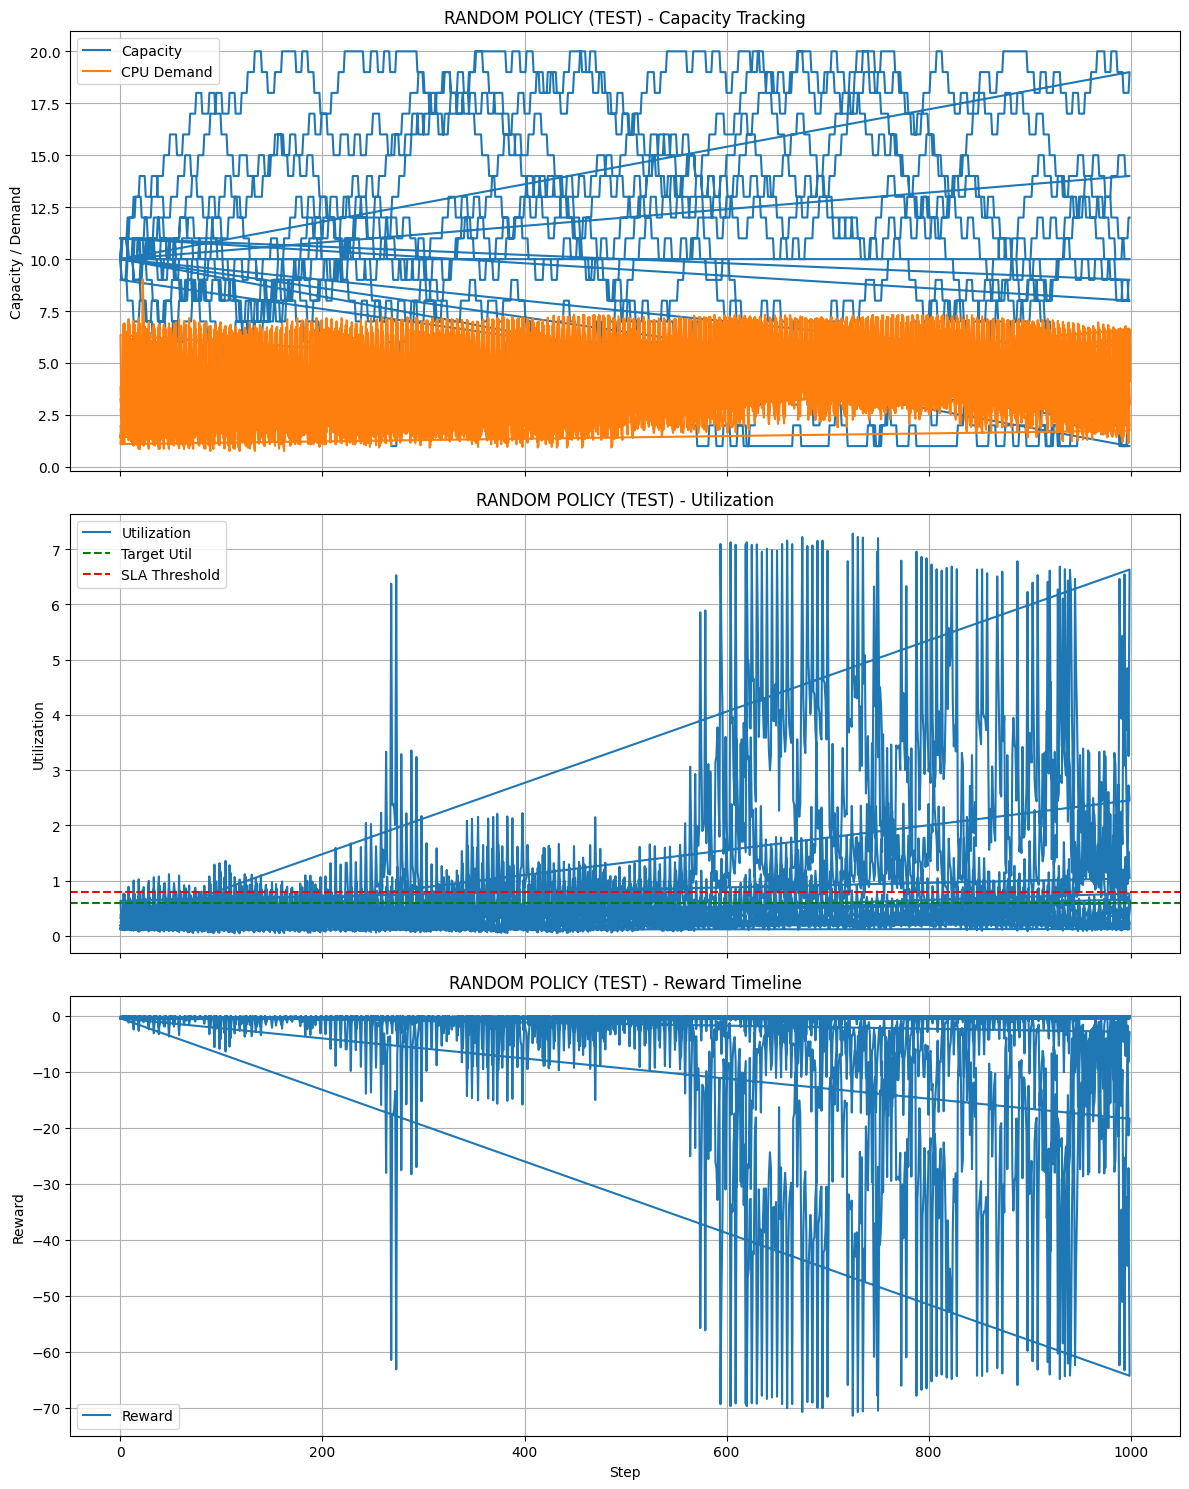

In [23]:
plot_evaluation_results(random_eval_test, "RANDOM POLICY (TEST)", env_random)


## Experiment 1 - DQN

In [1]:
raw_url_utilities = 'https://raw.githubusercontent.com/rah-ds/Cloud-Autoscaling-using-RL/refs/heads/bmcgregor/simulator-refactor/scripts/DQN_Utils.py'
local_filename_utilities = 'DQN_Utils.py'
!wget -O {local_filename_utilities} {raw_url_utilities}

--2025-11-26 03:06:03--  https://raw.githubusercontent.com/rah-ds/Cloud-Autoscaling-using-RL/refs/heads/bmcgregor/simulator-refactor/scripts/DQN_Utils.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 8145 (8.0K) [text/plain]
Saving to: ‘DQN_Utils.py’

DQN_Utils.py        100%[===================>]   7.95K  --.-KB/s    in 0s      

2025-11-26 03:06:03 (93.4 MB/s) - ‘DQN_Utils.py’ saved [8145/8145]



In [2]:
raw_url_dqn_agent = 'https://raw.githubusercontent.com/rah-ds/Cloud-Autoscaling-using-RL/refs/heads/bmcgregor/simulator-refactor/scripts/DQN_Agent.py'
local_filename_dqn_agent = 'DQN_Agent.py'
!wget -O {local_filename_dqn_agent} {raw_url_dqn_agent}

--2025-11-26 03:06:03--  https://raw.githubusercontent.com/rah-ds/Cloud-Autoscaling-using-RL/refs/heads/bmcgregor/simulator-refactor/scripts/DQN_Agent.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.111.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2727 (2.7K) [text/plain]
Saving to: ‘DQN_Agent.py’

DQN_Agent.py        100%[===================>]   2.66K  --.-KB/s    in 0s      

2025-11-26 03:06:03 (51.3 MB/s) - ‘DQN_Agent.py’ saved [2727/2727]



In [3]:

raw_url = 'https://raw.githubusercontent.com/rah-ds/Cloud-Autoscaling-using-RL/refs/heads/bmcgregor/simulator-refactor/scripts/autoscaling_env.py'



# Replace with the desired local filename for your script
local_filename = 'autoscaling_env.py'

!wget -O {local_filename} {raw_url}

--2025-11-26 03:06:03--  https://raw.githubusercontent.com/rah-ds/Cloud-Autoscaling-using-RL/refs/heads/bmcgregor/simulator-refactor/scripts/autoscaling_env.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 8002 (7.8K) [text/plain]
Saving to: ‘autoscaling_env.py’

autoscaling_env.py  100%[===================>]   7.81K  --.-KB/s    in 0s      

2025-11-26 03:06:03 (110 MB/s) - ‘autoscaling_env.py’ saved [8002/8002]



In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
import pandas as pd

df_usage = pd.read_csv('/content/drive/MyDrive/df_usage.csv')
display(df_usage.head())

,time_window,avg_cpu,avg_mem,active_machines
0,1970-01-01 00:05:00+00:00,0.006623,0.004912,9525
1,1970-01-01 00:06:00+00:00,0.003254,0.002733,3805
2,1970-01-01 00:07:00+00:00,0.003070,0.002770,4167
3,1970-01-01 00:08:00+00:00,0.001950,0.001823,4338
4,1970-01-01 00:09:00+00:00,0.001689,0.001468,5545


In [6]:
import sys
# Add the current directory to the system path to ensure Colab can find your local .py files
sys.path.append('.')


In [7]:
df_usage = df_usage.drop(columns=['active_machines']).copy()
display(df_usage.head())

,time_window,avg_cpu,avg_mem
0,1970-01-01 00:05:00+00:00,0.006623,0.004912
1,1970-01-01 00:06:00+00:00,0.003254,0.002733
2,1970-01-01 00:07:00+00:00,0.003070,0.002770
3,1970-01-01 00:08:00+00:00,0.001950,0.001823
4,1970-01-01 00:09:00+00:00,0.001689,0.001468


#DQN Experiment

Using device: cuda
Episode 0	Average Score: -6689.34
Episode 10	Average Score: -2525.17
Episode 20	Average Score: -447.24
Episode 30	Average Score: -632.76
Episode 40	Average Score: -430.54
Episode 50	Average Score: -414.52
Episode 60	Average Score: -408.97
Episode 70	Average Score: -409.99
Episode 80	Average Score: -422.81
Episode 90	Average Score: -420.35
Episode 100	Average Score: -418.46
Episode 110	Average Score: -420.94
Episode 120	Average Score: -414.53
Episode 130	Average Score: -436.11
Episode 140	Average Score: -421.08
Episode 150	Average Score: -417.05
Episode 160	Average Score: -418.19
Episode 170	Average Score: -410.81
Episode 180	Average Score: -389.12
Episode 190	Average Score: -386.90
Episode 200	Average Score: -366.47
Episode 210	Average Score: -369.50
Episode 220	Average Score: -354.62
Episode 230	Average Score: -352.04
Episode 240	Average Score: -362.60
Episode 250	Average Score: -339.46
Episode 260	Average Score: -333.03
Episode 270	Average Score: -321.51
Episode 28

NameError: name 'evaluation_results_df_dqn' is not defined

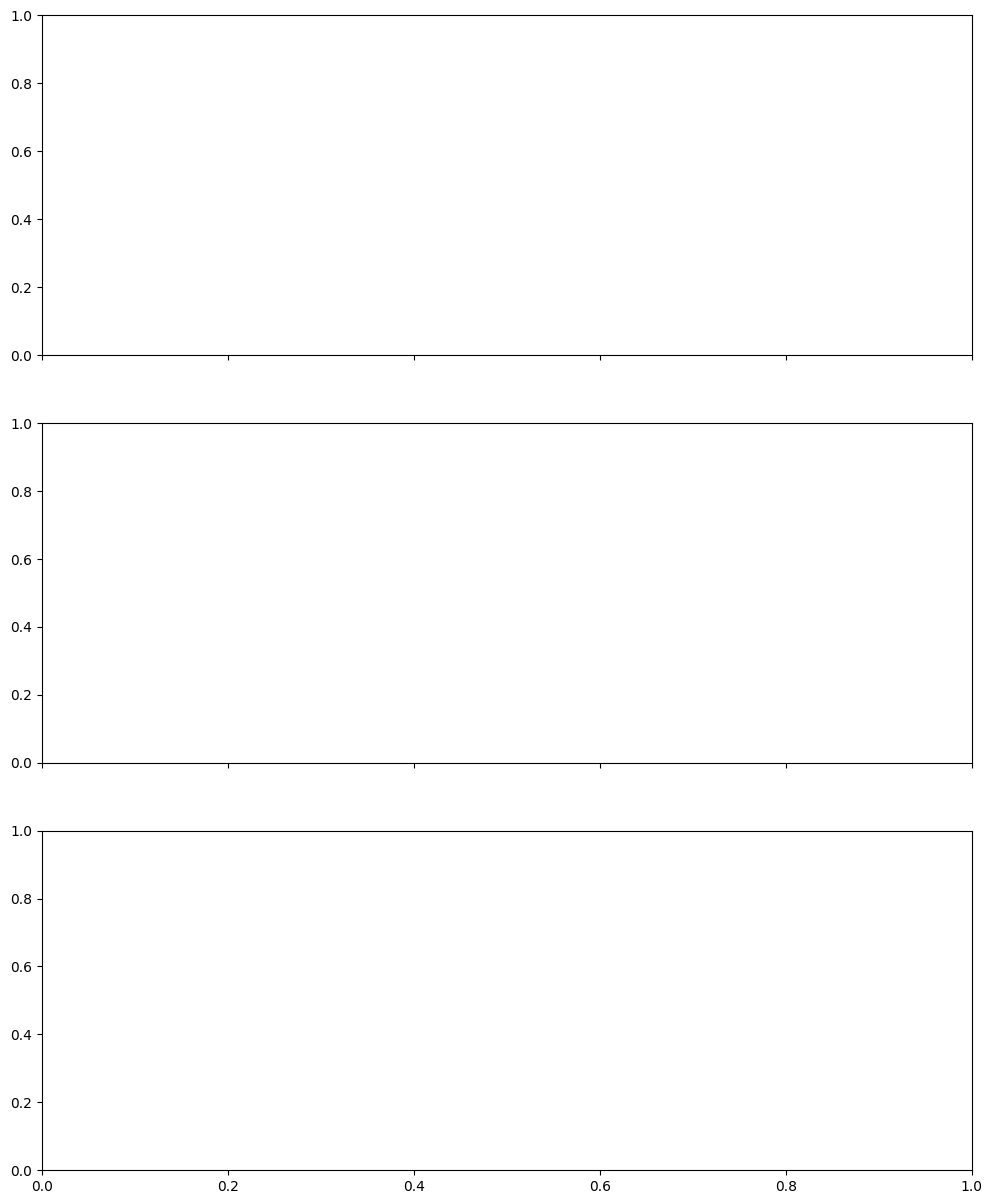

In [8]:

from autoscaling_env import AutoScalingEnv
from DQN_Utils import train_agent, evaluate_agent, QNetwork, ReplayBuffer
from DQN_Agent import DQNAgent
import numpy as np
import sys
import matplotlib.pyplot as plt # Import missing plt for plotting
import torch # Import torch to define the device

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# 1. Initialize the AutoScalingEnv environment for the DQN agent
env_dqn = AutoScalingEnv(df_usage)

# 2. Instantiate the DQNAgent
agent_dqn = DQNAgent(
    observation_space_shape=env_dqn.observation_space.shape,
    action_space_size=env_dqn.action_space.n,
    seed=0,
    device=device
)

# 3. Define the training hyperparameters for the DQN agent
num_episodes_dqn = 500
max_steps_per_episode_dqn = 1000
epsilon_start_dqn = 1.0
epsilon_end_dqn = 0.01
epsilon_decay_dqn = 0.995

# 4. Call the train_agent function
dqn_training_scores = train_agent(
    agent_dqn,
    env_dqn,
    num_episodes_dqn,
    max_steps_per_episode_dqn,
    epsilon_start_dqn,
    epsilon_end_dqn,
    epsilon_decay_dqn,
    split="train",
    use_random_windows = True
)

print("DQN Training Scores:", dqn_training_scores[:5]) # Display first 5 scores for brevity



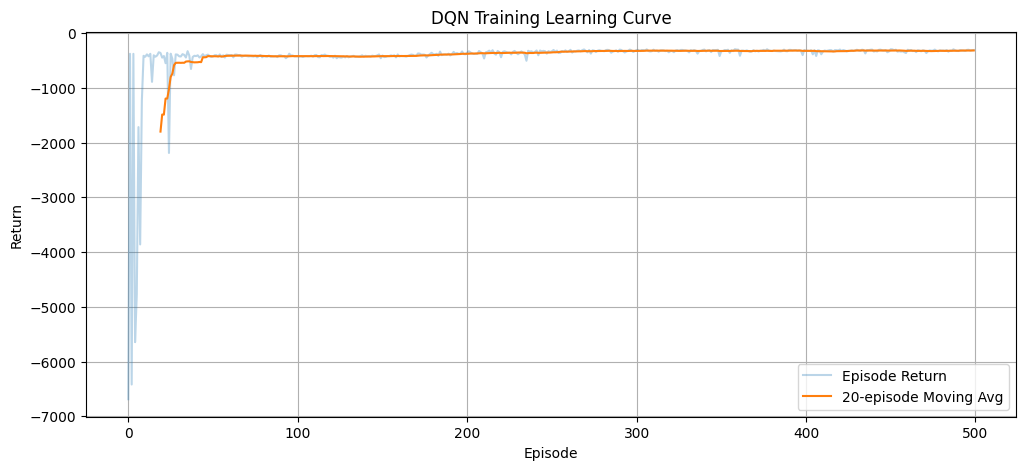

In [14]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Build a DataFrame of training returns
training_df = pd.DataFrame({
    "episode": np.arange(len(dqn_training_scores)),
    "return": dqn_training_scores
})

# 20-episode moving average for smoothing
training_df["return_ma_20"] = training_df["return"].rolling(window=20).mean()

# Plot learning curve
plt.figure(figsize=(12, 5))
plt.plot(training_df["episode"], training_df["return"],
         alpha=0.3, label="Episode Return")
plt.plot(training_df["episode"], training_df["return_ma_20"],
         label="20-episode Moving Avg")
plt.xlabel("Episode")
plt.ylabel("Return")
plt.title("DQN Training Learning Curve")
plt.legend()
plt.grid(True)
plt.show()


Evaluation Episode 1	Score: -311.87
Evaluation Episode 2	Score: -300.11
Evaluation Episode 3	Score: -301.51
Evaluation Episode 4	Score: -321.75
Evaluation Episode 5	Score: -313.50
Evaluation Episode 6	Score: -309.83
Evaluation Episode 7	Score: -318.22
Evaluation Episode 8	Score: -301.32
Evaluation Episode 9	Score: -303.06
Evaluation Episode 10	Score: -315.00

Average Evaluation Score over 10 episodes: -309.62
Evaluation Episode 1	Score: -261.29
Evaluation Episode 2	Score: -286.50
Evaluation Episode 3	Score: -256.79
Evaluation Episode 4	Score: -277.21
Evaluation Episode 5	Score: -284.20
Evaluation Episode 6	Score: -256.89
Evaluation Episode 7	Score: -265.90
Evaluation Episode 8	Score: -261.19
Evaluation Episode 9	Score: -290.43
Evaluation Episode 10	Score: -290.19

Average Evaluation Score over 10 episodes: -273.06


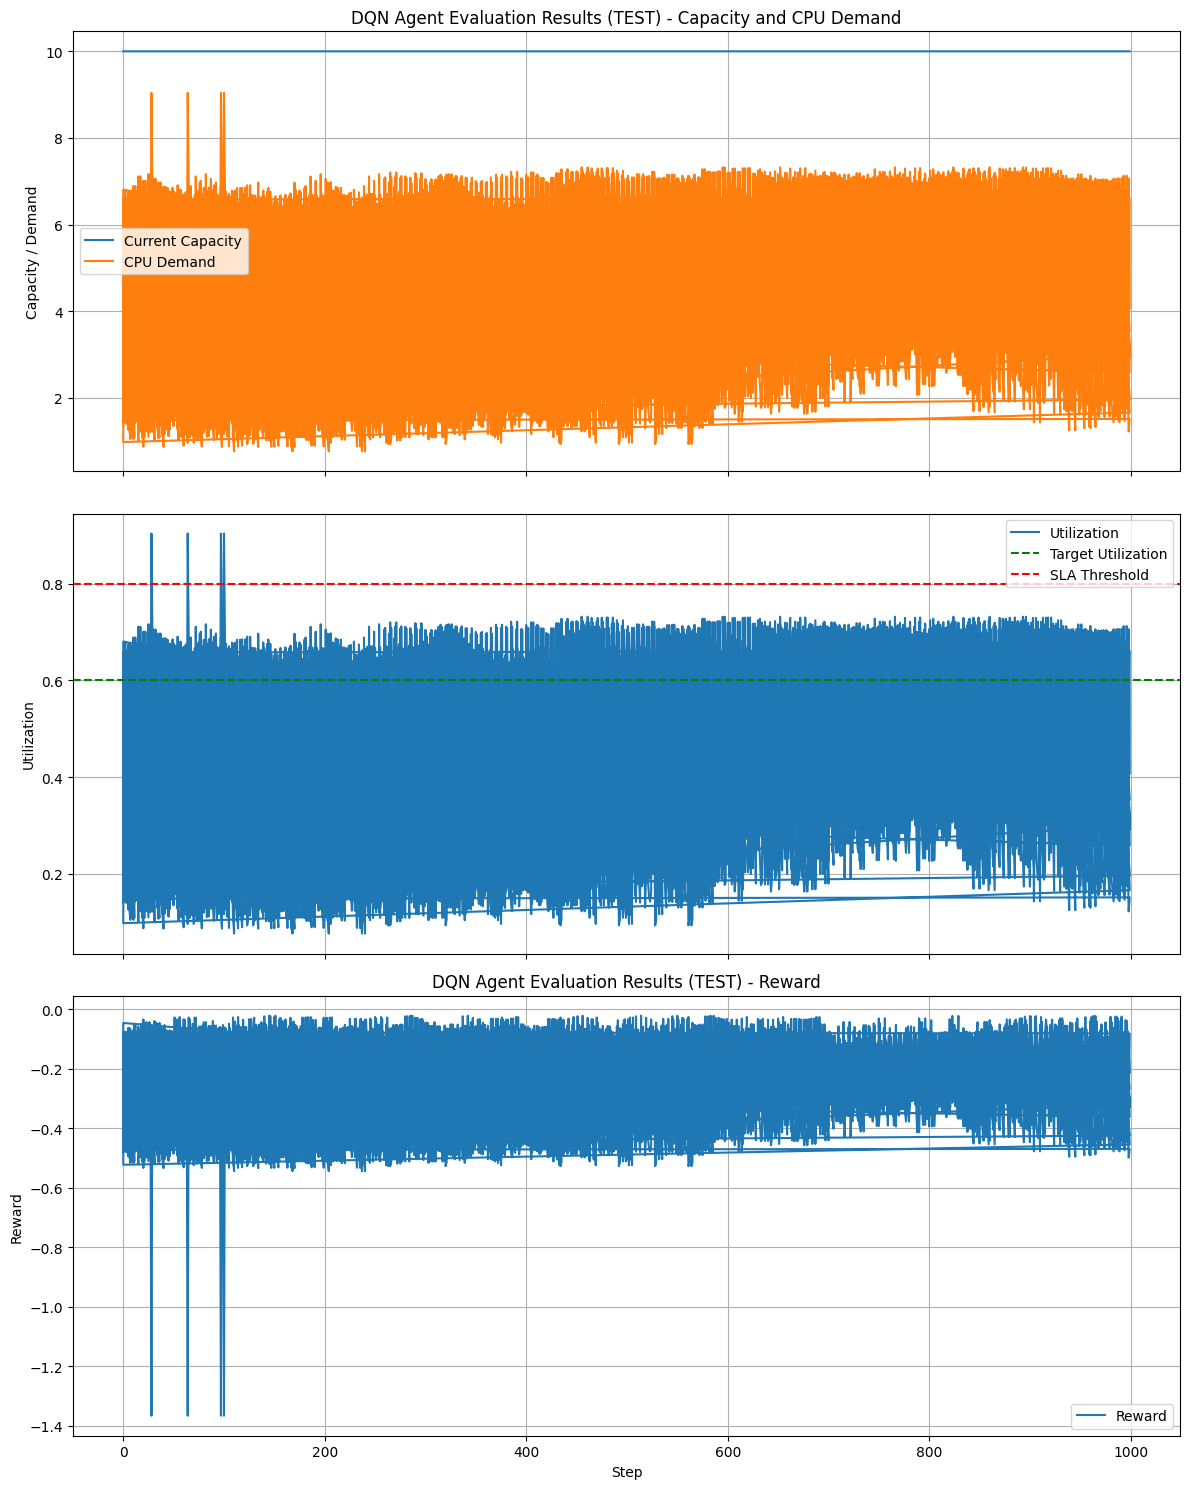

In [10]:
# 5. Define the evaluation hyperparameters for the DQN agent
num_evaluation_episodes_dqn = 10
max_steps_per_evaluation_episode_dqn = 1000

# 6. Call the evaluate_agent functions

# Validation evaluation
dqn_val_scores, eval_results_val = evaluate_agent(
    agent_dqn,
    env_dqn,
    num_evaluation_episodes_dqn,
    max_steps_per_evaluation_episode_dqn,
    split="val",
    use_random_windows=True
)

# Test evaluation
dqn_test_scores, eval_results_test = evaluate_agent(
    agent_dqn,
    env_dqn,
    num_evaluation_episodes_dqn,
    max_steps_per_evaluation_episode_dqn,
    split="test",
    use_random_windows=True
)

# Choose which split to plot
df = eval_results_test      # or eval_results_val if you want validation

# 7. Create a figure and a set of subplots
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(12, 15), sharex=True)

# 8. Plot Current Capacity and CPU Demand
axes[0].plot(df.index, df['current_capacity'], label='Current Capacity')
axes[0].plot(df.index, df['demand_cpu'], label='CPU Demand')
axes[0].set_ylabel('Capacity / Demand')
axes[0].set_title('DQN Agent Evaluation Results (TEST) - Capacity and CPU Demand')
axes[0].legend()
axes[0].grid(True)

# 9. Plot Utilization and Target Utilization
axes[1].plot(df.index, df['utilization'], label='Utilization')
axes[1].axhline(y=env_dqn.target_utilization, color='g', linestyle='--', label='Target Utilization')
axes[1].axhline(y=env_dqn.sla_threshold, color='r', linestyle='--', label='SLA Threshold')
axes[1].set_ylabel('Utilization')
axes[1].legend()
axes[1].grid(True)

# 10. Plot Reward
axes[2].plot(df.index, df['reward'], label='Reward')
axes[2].set_xlabel('Step')
axes[2].set_ylabel('Reward')
axes[2].set_title('DQN Agent Evaluation Results (TEST) - Reward')
axes[2].legend()
axes[2].grid(True)

# 11. Adjust layout and display plots
plt.tight_layout()
plt.show()
